‎ 


# 0. Setup

In [1]:
from Requirements import *

from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
from tensorflow.keras.datasets import mnist

2025-10-10 10:48:40.137137: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-10 10:48:40.311500: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-10 10:48:40.493559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-10 10:48:40.636140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-10 10:48:40.671963: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-10 10:48:40.939133: I tensorflow/core/platform/cpu_feature_gu

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


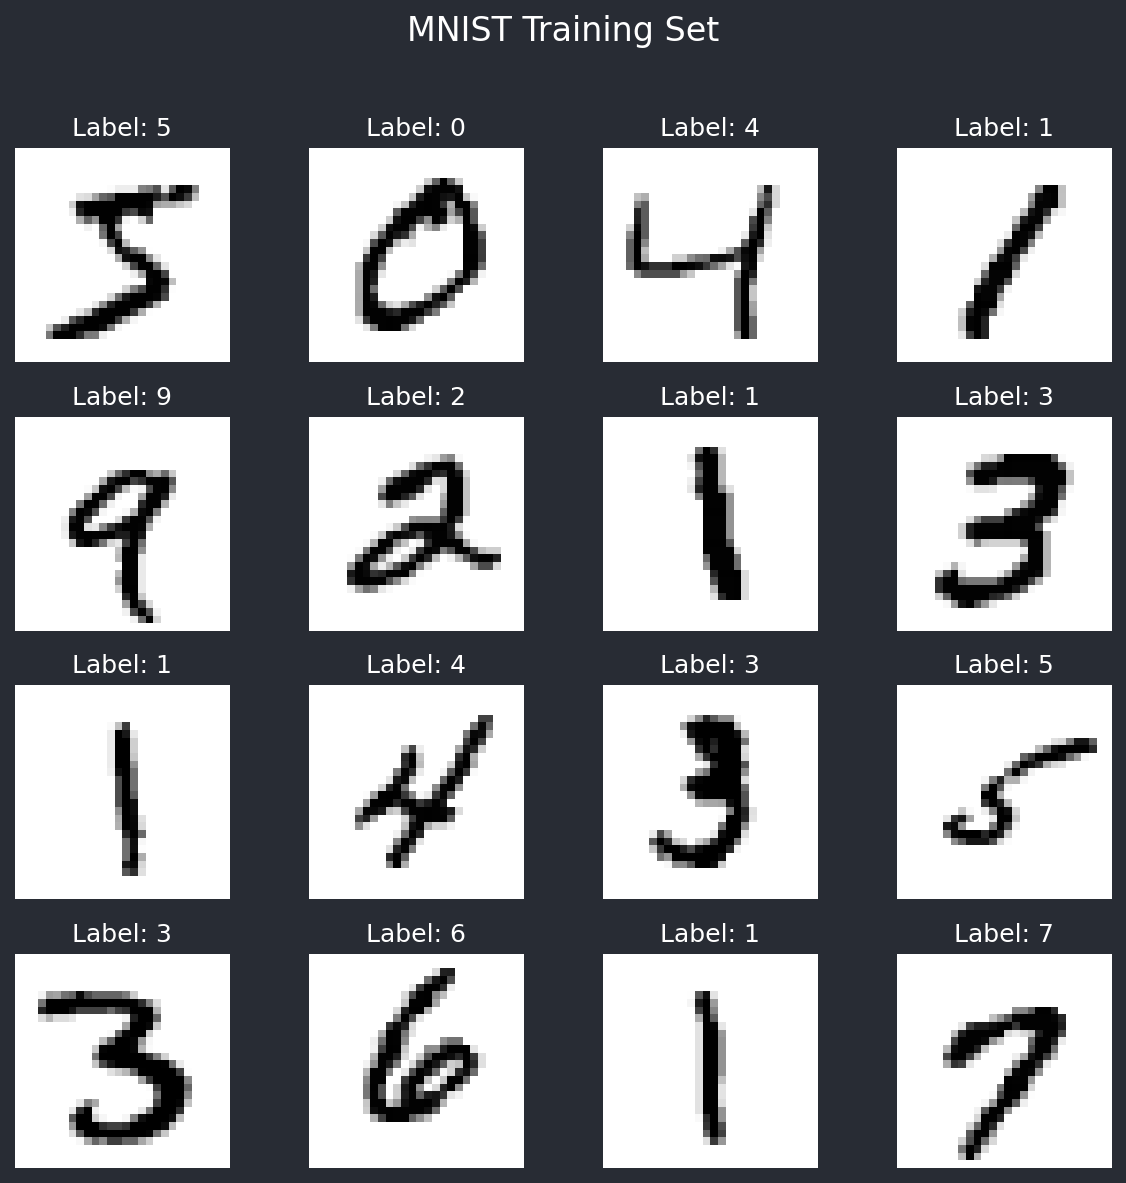

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):

    ax.imshow(x_train[i], cmap='gray_r')
    
    ax.set_title(f"Label: {y_train[i]}")
    
    ax.axis('off')

plt.suptitle("MNIST Training Set", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

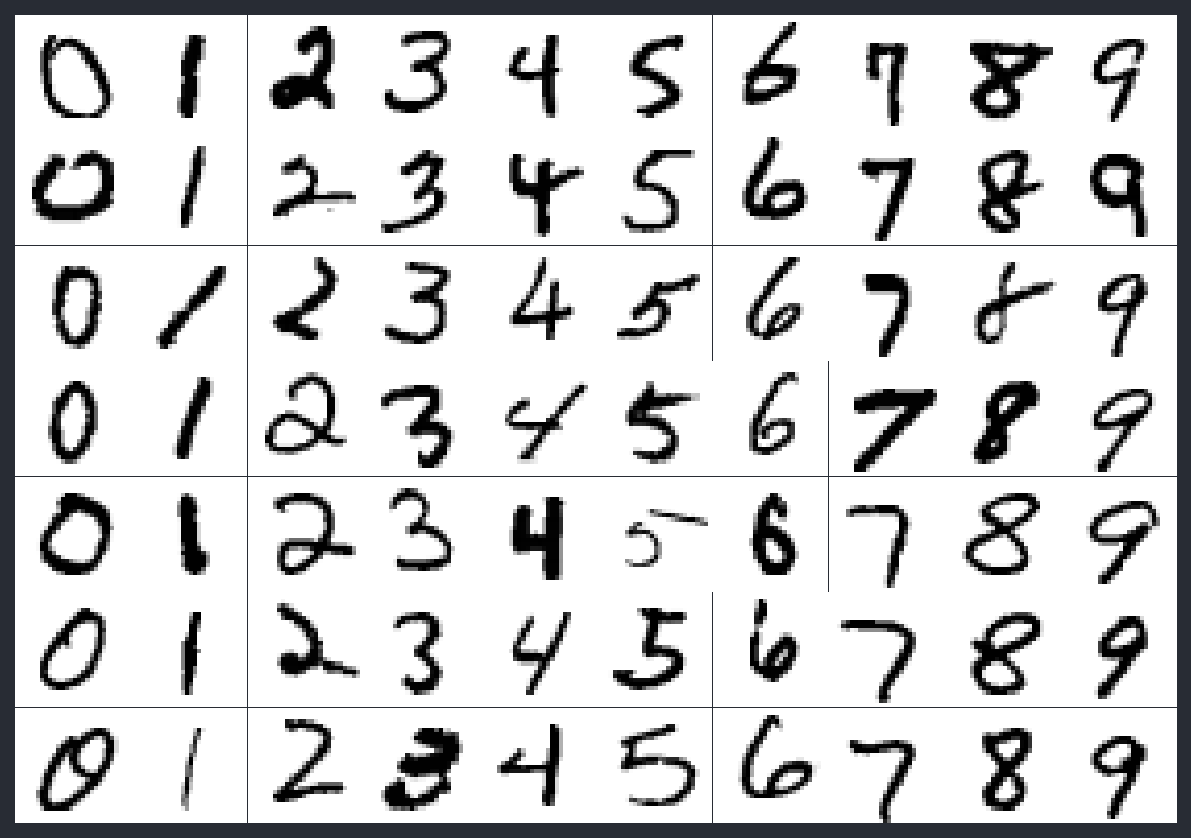

In [14]:
fig, axes = plt.subplots(7, 10, figsize=(10, 7))

# Adjust spacing to bring images closer
plt.subplots_adjust(wspace=0, hspace=0)

for digit in range(10): # Loop from 0 to 9 for 10 columns
    
    digit_indices = np.where(y_train == digit)[0]
    
    # Ensure there are enough samples to choose from
    if len(digit_indices) >= 7:
        selected_indices = np.random.choice(digit_indices, 7, replace=False)
    else:
        # If not enough, take what's available (with replacement if necessary)
        selected_indices = np.random.choice(digit_indices, 7, replace=True)

    for i, ax in enumerate(axes[:, digit]):
        
        ax.imshow(x_train[selected_indices[i]], cmap='gray_r')
        
        ax.axis('off')

plt.savefig('1. Data/3. Images/example_mnist.png', 
        transparent=False,          # Fundo sólido (branco)
        dpi=150,
        bbox_inches='tight',
        facecolor='white',          # Garante fundo branco
        edgecolor='none')

plt.show()

In [16]:
number_samples = 2500

x_train_new, _, y_train_new, _ = train_test_split(x_train, y_train, train_size = number_samples, random_state = 42, stratify = y_train)

x_test_new, _, y_test_new, _ = train_test_split(x_test, y_test, train_size = int(number_samples/10), random_state = 42, stratify = y_test)

train_counts = Counter(y_train_new)
test_counts = Counter(y_test_new)

headers = sorted(train_counts.keys())
train_row = ["Train",] + [train_counts[d] for d in headers]
test_row = ["Test",] + [test_counts[d] for d in headers]
train_percentage_row = ["Train %",] + [f"{(train_counts[d]/number_samples)*100:.1f}%" for d in headers]
test_percentage_row = ["Test %",] + [f"{(test_counts[d]/(number_samples/10))*100:.1f}%" for d in headers]

print(f"\nDistribution of digits in the training set (n={number_samples}):\n")
print(tabulate([train_row, train_percentage_row], headers=["Set"] + headers))

print("\n" + "-"*50 + "\n")

print(f"\nDistribution of digits in the test set (n={int(number_samples/10)}):\n")
print(tabulate([test_row, test_percentage_row], headers=["Set"] + headers))



Distribution of digits in the training set (n=2500):

Set      0     1      2     3      4     5     6     7      8     9
-------  ----  -----  ----  -----  ----  ----  ----  -----  ----  ----
Train    247   281    248   255    243   226   247   261    244   248
Train %  9.9%  11.2%  9.9%  10.2%  9.7%  9.0%  9.9%  10.4%  9.8%  9.9%

--------------------------------------------------


Distribution of digits in the test set (n=250):

Set     0      1      2      3      4      5     6     7      8     9
------  -----  -----  -----  -----  -----  ----  ----  -----  ----  -----
Test    25     28     26     25     25     22    24    26     24    25
Test %  10.0%  11.2%  10.4%  10.0%  10.0%  8.8%  9.6%  10.4%  9.6%  10.0%


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:

x_train_flat = x_train_new.reshape(x_train_new.shape[0], -1)
x_test_flat = x_test_new.reshape(x_test_new.shape[0], -1)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled = scaler.transform(x_test_flat)

In [19]:
pca_components = 16

pca = PCA(n_components = pca_components)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Shape of PCA-transformed x_train:", x_train_pca.shape)
print("Shape of PCA-transformed x_test:", x_test_pca.shape)

Shape of PCA-transformed x_train: (2500, 16)
Shape of PCA-transformed x_test: (250, 16)


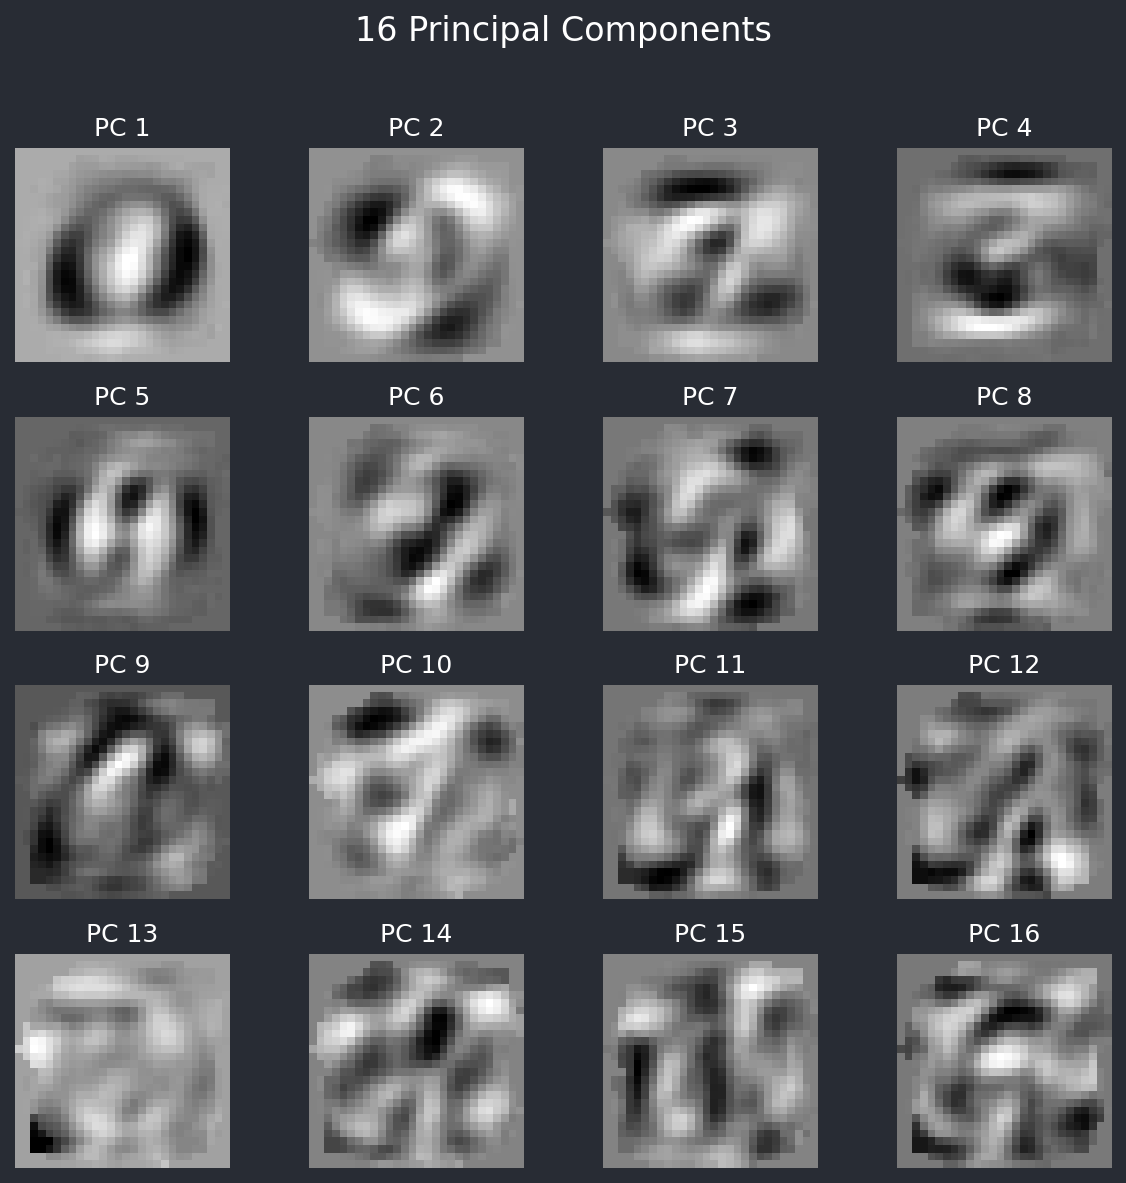

In [20]:
from matplotlib.pyplot import savefig


fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
    
plt.suptitle(f"{pca_components} Principal Components", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


In [ ]:
if False : 
    
    plt.style.use('default')  # Ou usar 'seaborn-white', 'classic'

    plt.rcParams.update({
        'figure.facecolor':   'white',  
        'axes.facecolor':     'white',    
        'text.color':         'black',      # Cor do texto geral
        'axes.labelcolor':    'black',      # Cor dos labels dos eixos
        'xtick.color':        'black',      # Cor dos ticks do eixo X
        'ytick.color':        'black',      # Cor dos ticks do eixo Y
        'grid.color':         '#dddddd',    # Grid mais suave

        'figure.figsize': (16, 4),          # Ajustado para 8x2
        'figure.dpi': 150
    })

    # Criar figura com 2 linhas e 8 colunas
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))

    for i, ax in enumerate(axes.flat):
        if i < len(pca.components_):  # Evitar erro se tiver menos componentes
            ax.imshow(pca.components_[i].reshape(28, 28), cmap='gray')
            ax.set_title(f"PC {i+1}", color='black')  # Texto preto
            ax.axis('off')
        else:
            ax.axis('off')  # Desliga eixos vazios
        
    plt.suptitle(f"{pca_components} Principal Components", fontsize=16, color='black')
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    savefig('pca_components.png', 
            transparent=False,          # Fundo sólido (branco)
            dpi=150,
            bbox_inches='tight',
            facecolor='white',          # Garante fundo branco
            edgecolor='none')

    plt.show()

‎ 

# 1. Quantum Loop

In [22]:
def get_quantum_distance(vec_alpha, vec_vj, shots=1024):

    num_qubits_per_state = int(np.log2(len(vec_alpha)))
    
    qc = QuantumCircuit(1 + 2 * num_qubits_per_state, 1)

    alpha_qubits = list(range(1, num_qubits_per_state + 1))
    vj_qubits = list(range(num_qubits_per_state + 1, 1 + 2 * num_qubits_per_state))
    
    qc.initialize(vec_alpha, alpha_qubits)
    qc.initialize(vec_vj, vj_qubits)
    
    ancilla_qubit = 0
    qc.h(ancilla_qubit)
    for i in range(num_qubits_per_state):
        qc.cswap(ancilla_qubit, alpha_qubits[i], vj_qubits[i])
    qc.h(ancilla_qubit)
    
    qc.measure(ancilla_qubit, 0)
    
    simulator = AerSimulator()
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()
    
    distance = counts.get('1', 0) / shots
    return distance


In [23]:
from operator import index


results_list = []
simulator = AerSimulator()

for i in tqdm(range(x_test_pca.shape[0])):
    
    test_vector = x_test_pca[i]
    test_label = y_test_new[i]
    
    norm_test_vector = np.linalg.norm(test_vector)
    
    if norm_test_vector == 0: continue
    
    normed_test_vector = test_vector / norm_test_vector
    
    for j in range(x_train_pca.shape[0]):
        
        train_vector = x_train_pca[j]
        train_label = y_train_new[j]
        
        norm_train_vector = np.linalg.norm(train_vector)
        
        if norm_train_vector == 0: continue
        
        normed_train_vector = train_vector / norm_train_vector
        
        distance = get_quantum_distance(normed_test_vector, normed_train_vector)

        results_list.append({'test_index': i, 'test_label': test_label, 'train_index': j, 'train_label': train_label, 'distance': distance})


  0%|          | 0/250 [00:00<?, ?it/s]

In [32]:
if True: 
    
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/qknn_hybrid_2500.pkl", "wb") as f:
        
        pickle.dump(results_list, f)

if False: 
    
    with open("1. Data/4. Pickles/1. Quantum Machine Learning/qknn_hybrid_2500.pkl", "rb") as f:
        
        results_list = pickle.load(f)

In [31]:
results_df = pd.DataFrame(results_list)

display(results_df)

print(f"\nDataFrame shape: {results_df.shape}")

,test_index,test_label,train_index,train_label,distance
0,0,0,0,1,0.494141
1,0,0,1,1,0.455078
2,0,0,2,2,0.492188
3,0,0,3,4,0.502930
4,0,0,4,0,0.395508
...,...,...,...,...,...
624995,249,8,2495,4,0.360352
624996,249,8,2496,2,0.526367
624997,249,8,2497,9,0.420898
624998,249,8,2498,0,0.501953



DataFrame shape: (625000, 5)


In [33]:
from scipy import stats
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [34]:
k = 5

predictions = []

test_indices = results_df['test_index'].unique()

for i in test_indices:
    
    neighbors = results_df[results_df['test_index'] == i]
    
    k_nearest_neighbors = neighbors.sort_values(by='distance').head(k)

    predicted_label = stats.mode(k_nearest_neighbors['train_label'], keepdims=False).mode
    
    true_label = k_nearest_neighbors['test_label'].iloc[0]

    predictions.append({'Test Image Index': i, 'True Label': true_label, 'Predicted Label': predicted_label, 'Correct': predicted_label == true_label})
    
df_predictions = pd.DataFrame(predictions)


In [35]:
display(df_predictions.head(10))

accuracy_score = accuracy_score(df_predictions['True Label'], df_predictions['Predicted Label'])

print(f"\nAccuracy: {accuracy_score*100:.2f}%")

,Test Image Index,True Label,Predicted Label,Correct
0,0,0,0,True
1,1,7,7,True
2,2,1,1,True
3,3,4,4,True
4,4,3,3,True
5,5,8,8,True
6,6,9,9,True
7,7,3,3,True
8,8,6,6,True
9,9,4,4,True



Accuracy: 88.80%


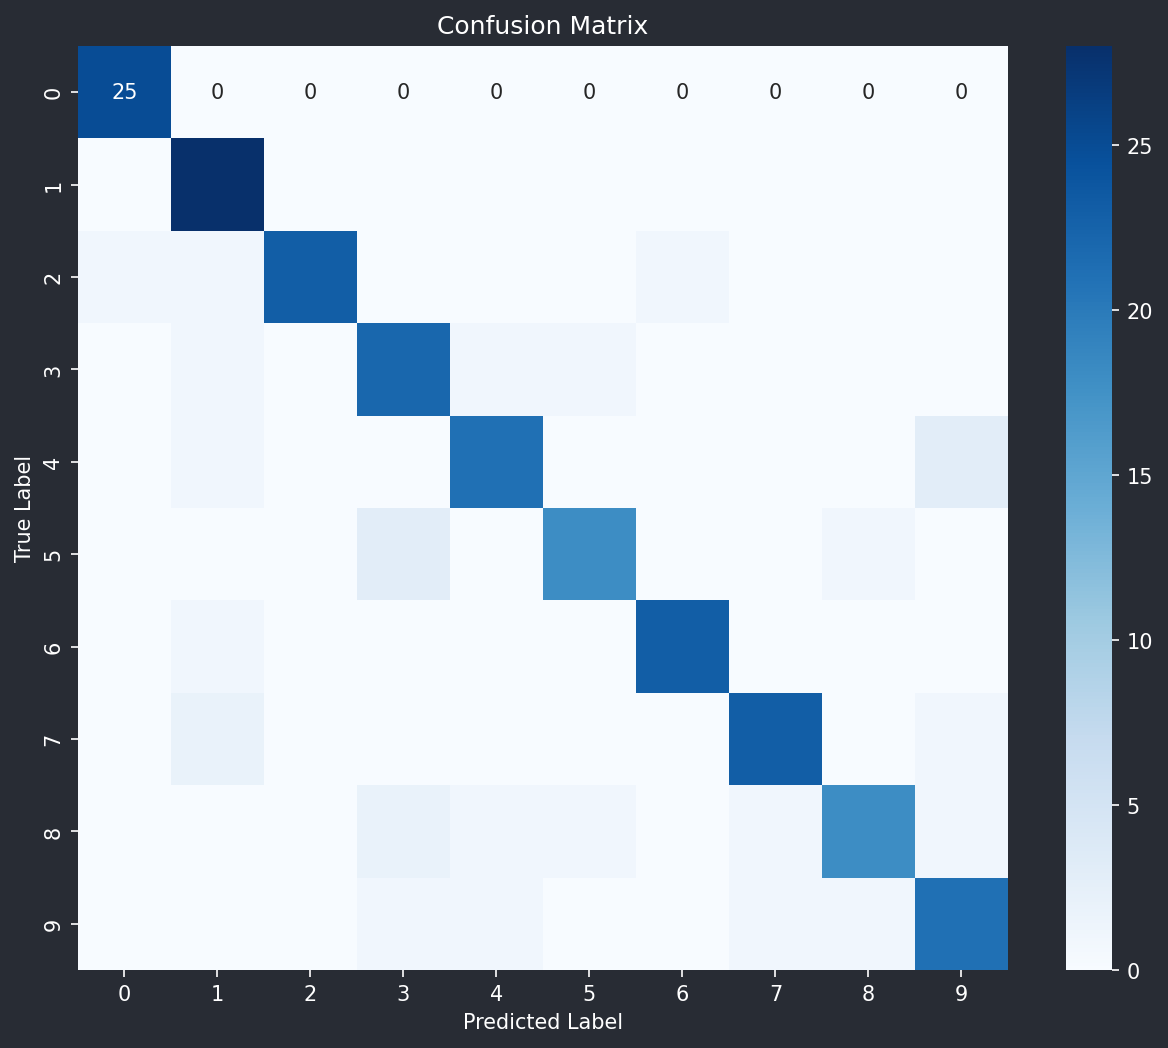

In [36]:

conf_matrix = confusion_matrix(df_predictions['True Label'], df_predictions['Predicted Label'])

plt.figure(figsize=(10, 8))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

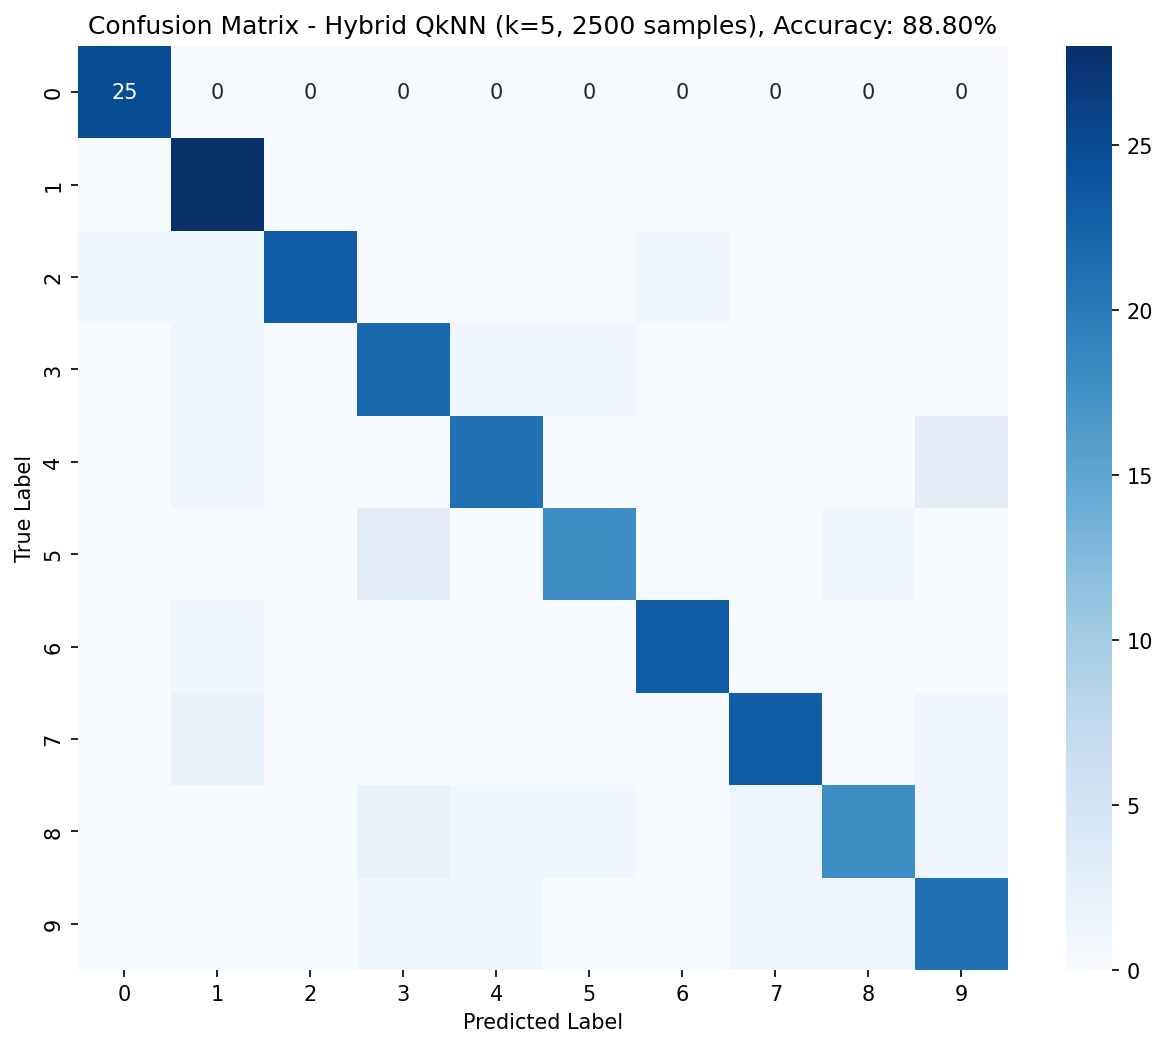

In [ ]:
plt.style.use('default')  # Ou usar 'seaborn-white', 'classic'

plt.rcParams.update({
    'figure.facecolor':   'white',  
    'axes.facecolor':     'white',    
    'text.color':         'black',      # Cor do texto geral
    'axes.labelcolor':    'black',      # Cor dos labels dos eixos
    'xtick.color':        'black',      # Cor dos ticks do eixo X
    'ytick.color':        'black',      # Cor dos ticks do eixo Y
    'grid.color':         '#dddddd',    # Grid mais suave

    'figure.figsize': (16, 4),          # Ajustado para 8x2
    'figure.dpi': 150
})

conf_matrix = confusion_matrix(df_predictions['True Label'], df_predictions['Predicted Label'])

plt.figure(figsize=(10, 8))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix - Hybrid QkNN (k={k}, {number_samples} samples), Accuracy: {accuracy_score*100:.2f}%')

savefig('confusion_matrix.png', 
        transparent=False,          
        dpi=150,
        bbox_inches='tight',
        facecolor='white',          
        edgecolor='none')

plt.show()